# Greitzer's model 3DOF non-linear
In this notebook we will present a non-linear solution of the Greitzer's Surge model (3D). The aim of this notebook is to show limit cycles as solution to $3^{rd}$ order systems

## Import statements

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.optimize import fsolve

## plots configurations

In [17]:
plt.rc('text', usetex=False)      
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)
plt.rcParams['font.size'] = 10
format_fig = (8, 5)

## Parameters set
this set of parameters leads to a limit cycle solution

In [4]:
N = 80e3                                    #[rpm] --> large N enlarges the cirle
r_ref = 13e-3                               #radius [m]
omega = 2*np.pi*N/60                        #[rad/s]
U_ref = omega*r_ref                         #reference speed of compressor[m/s]
a = 340                                     #speed of sound [m/s]
dc = 30.4e-3                                #inlet diameter [m]
Ac = (np.pi*dc**2)/4                        #inlet area [m2]
Lc = 2                                      #inlet length [m]
dt = 25e-3                                  #throttle diameter [m]
At = (np.pi*dt**2)/4                        #throttle area [m2]
Lt = 2                                      #throttle length [m]
Vp = (At*Lt + Ac*Lc)*100                    #plenum volume [m3]
B_real = 2.0*(U_ref/(2*a))*np.sqrt(Vp/(Ac*Lc))         #B parameter of the described compressor
G_real = Lt*Ac/(Lc*At)                      #G parameter of the described compressor
k_valve = 4.2

## Compressor and throttle valve models
the compressor is modeled with a cubic function, described in the papers of Moore and Greitzer. The throttle is modeled as a quadratic function of the mass flow rate

In [6]:
phi = np.linspace(0,1,100)

#calculation of unstalled curve 
def unstalled_characteristic(phi, H=0.35/2, W=0.2, psi_c_0=0.3):
    """
    It computes the unstalled characteristic of the compressor using the cubic model

    Arguments:
        phi :  flow coefficient
        H : H parameter
        W : W parameter
        psi_c_0 : performance at zero flow coefficient
    """
    return psi_c_0 + H * (1 + 1.5*(phi/W - 1) - 0.5*(phi/W -1)**3)

psi_c = unstalled_characteristic(phi)

#throttle valve curve, only specified from k_valve
psi_v = k_valve*phi**2

## equilibrium point
find the equilibrium point of the system as an intersection between the compressor and valve curves

In [7]:
#find the intersection flow coefficient between compressor and throttle
def func_work_coefficient(phi):
    """
    Function needed by fsolve in order to find the intersection between unstalled
    compressor curve and throttle line
    """
    return unstalled_characteristic(phi) - k_valve*phi**2

initial_phi_guess = 0.3 #initial guess of intersection
phi_eq = fsolve(func_work_coefficient,initial_phi_guess) #intersection, operating point
psi_eq = k_valve*phi_eq**2 #intersection, operating point

#calculate derivatives of the compressor and throttle characteristic at equilibrium point
delta_phi = phi_eq*0.001
phi_left = phi_eq - delta_phi
phi_right = phi_eq + delta_phi
psi_c_right = unstalled_characteristic(phi_right)
psi_c_left = unstalled_characteristic(phi_left)
psi_c_prime = (psi_c_right - psi_c_left) / (2*delta_phi)
psi_v_prime = 2*k_valve*phi_eq

## plot the compressor curve

(0.0, 0.8)

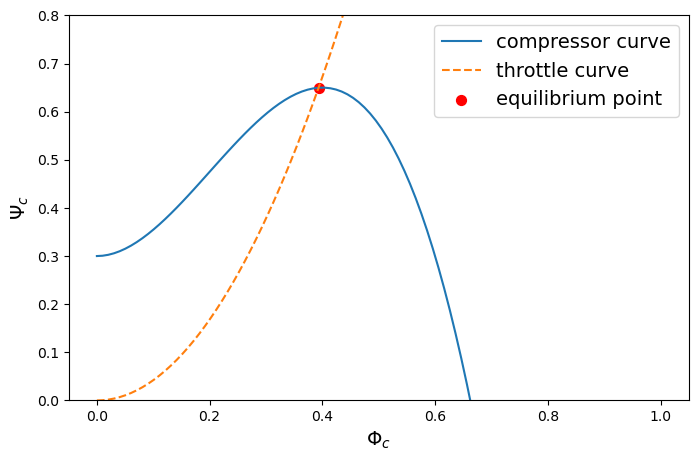

In [9]:
plt.figure(figsize=format_fig)
plt.plot(phi, psi_c, linewidth=1.5, label='compressor curve')
plt.plot(phi, psi_v, '--', linewidth=1.5, label='throttle curve')
plt.scatter(phi_eq, psi_eq, color='red', s=50, label='equilibrium point')
plt.ylabel(r'$\Psi_c$')
plt.xlabel(r'$\Phi_c$')
plt.legend()
plt.ylim(0, 0.8)

## solve the governing equations
the three governing equations are defined in Greitzer function in non-dimensional form. The initial condition (small with respect to the equilibrium values) is prescribed in y0.

In [10]:
def Greitzer(y, xi, B, G, k_valve, closure_coeff):
    """
    Defines the differential equations for the Greitzer model
    (as found in the thesis of Sündstrom).

    Arguments:
        y :  vector of the state variables
        xi : non dimensional time
        B :  B parameter
        G :  G parameter
        closure_coeff : the initial perturbation is modeled as a closure of the valve (increase of k_valve)
    
    State variables:
        x1 : compressor flow coefficient
        x2 : throttle flow coefficient
        x3 : compressor work coefficient
    """
    x1, x2, x3 = y
    dydt = [B * (unstalled_characteristic(x1) - x3),
            (x3 - closure_coeff*k_valve*x2**2) * B/G,
            (x1-x2)/B]
    return dydt

#time span
t = np.linspace(0,20,5000)
xi = t*a*np.sqrt(Ac/(Vp*Lc))

#initial conditions
throttle_closure = 0.01 #perturbation to replicate linear analysis
y0 = [phi_eq[0]*(1-throttle_closure), 
      phi_eq[0]*(1+throttle_closure), 
      psi_eq[0]*(1-0.5*throttle_closure)] 

IC_flow_c = [y0[0]]
IC_flow_t = [y0[1]]
IC_psi = [y0[2]]

from scipy.integrate import odeint
closure_coeff = 1.0
sol = odeint(Greitzer, y0, xi, args=(B_real, G_real, k_valve, closure_coeff))
initialDerivative = Greitzer(y0, t[0], B_real, G_real, k_valve, closure_coeff)

## pictures folder
create the picture folder, in the path wanted

In [11]:
path = "pics"
isExist = os.path.exists(path)
if not isExist:
   os.makedirs(path)

## plot the temporal evolution of the perturbation states

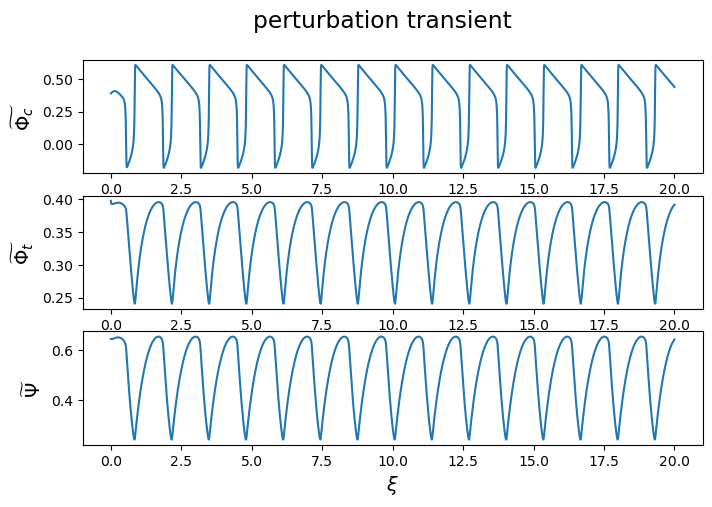

In [12]:
fig, axes = plt.subplots(3,1, figsize=format_fig)
axes[0].set_ylabel(r'$\widetilde{\Phi_{c}}$')
axes[0].plot(t,sol[:,0])
axes[1].set_ylabel(r'$\widetilde{\Phi_{t}}$')
axes[1].plot(t,sol[:,1])
axes[2].set_ylabel(r'$\widetilde{\Psi}$')
axes[2].plot(t,sol[:,2])
axes[2].set_xlabel(r'$\xi $')
fig.suptitle('perturbation transient')
fig.savefig(path+'/perturbation_transient.pdf', bbox_inches='tight')

## plot the perturbations in the phase space
plot simply how the the pressure increase changes as a function of the compressor mass flow rate. The other combinations are similar

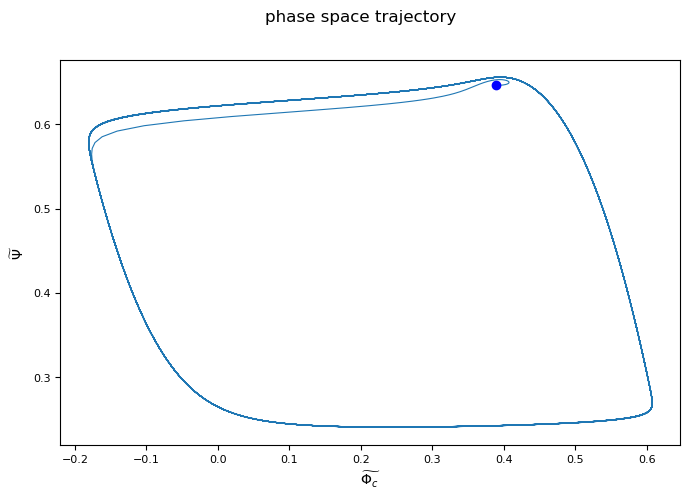

In [19]:
fig, axes = plt.subplots(figsize=format_fig)
axes.set_ylabel(r'$\widetilde{\Psi}$')
axes.set_xlabel(r'$\widetilde{\Phi_{c}}$')
axes.plot(sol[:, 0],sol[:, 2],linewidth=0.8)
axes.plot(IC_flow_c, IC_psi, marker='o', color='b', label='IC')
fig.suptitle('phase space trajectory')
fig.savefig(path+'/phase_space_perturbations.pdf', bbox_inches='tight')

## show the limit cycle

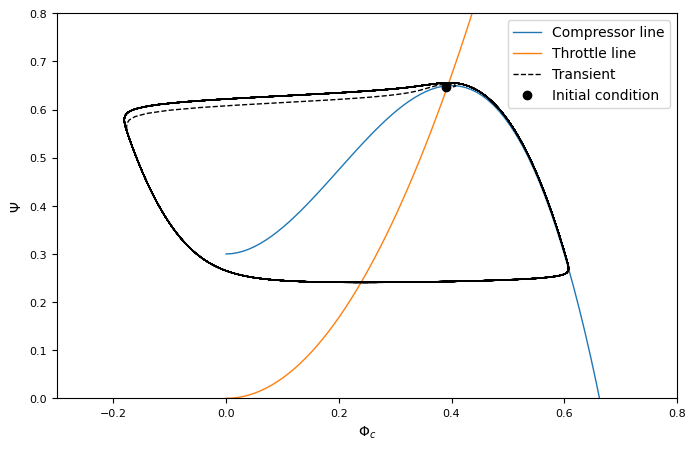

In [18]:
plt.figure(figsize=format_fig)
plt.plot(phi,psi_c,linewidth=1.0,label='Compressor line')
plt.plot(phi,psi_v,linewidth=1.0,label='Throttle line')
plt.plot(sol[:,0],sol[:,2],'--k',linewidth=1.0, label = 'Transient')
plt.plot(IC_flow_c, IC_psi, 'ko', label='Initial condition')
plt.ylabel(r'$\Psi$')
plt.xlabel(r'$\Phi_c$')
plt.legend()
plt.xlim(-0.3,0.8)
plt.ylim(0,0.8)
plt.savefig(path+'/limit_cycle.pdf', bbox_inches='tight')